# Exploratory Data Analysis

This section presents an exploratory data analysis of the **Telco Customer churn** dataset.

## Goals
- inspect the dataset structure;
- identify missing values and data quality issues;
- analyze the target variable 'Churn';
- study numerical and categorical features;
- identify important patterns related to customer churn;
- prepare the dataset for further modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print("Sample values in TotalCharges:")
print(df["TotalCharges"].head(10))

Sample values in TotalCharges:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


## Data Cleaning

The `TotalCharges` column is converted to numeric format. Any invalid entries are coerced into missing values and then removed.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

Missing values in TotalCharges after conversion: 11


In [ ]:
df = df.dropna(subset=["TotalCharges"]).copy()
print("Shape after dropping missing rows:", df.shape)

Shape after dropping missing rows: (7032, 21)


The 'customerID' column is removed because it is only an identifier and does not contain predictive information.

In [ ]:
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Target Variable

We analyze the class balance of the target variable 'Churn' to check for class imbalance.

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


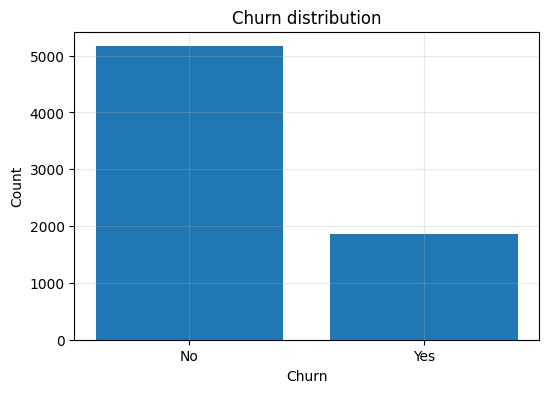

In [ ]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

## Class Balance

The dataset is moderately imbalanced:
- 73.4% of customers did not churn;
- 26.6% of customers churned.

This should be considered during model training and evaluation

## Numerical Features

In [ ]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


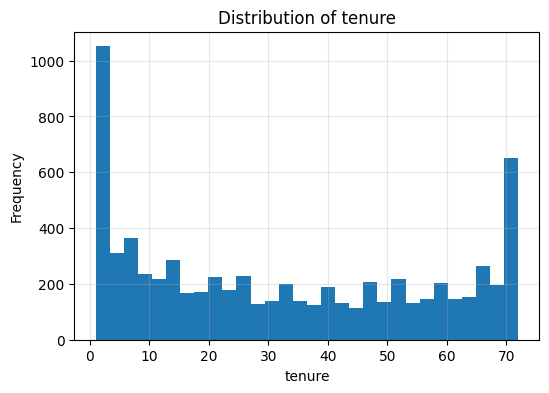

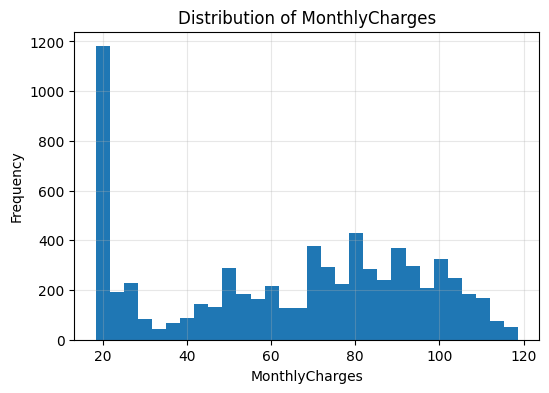

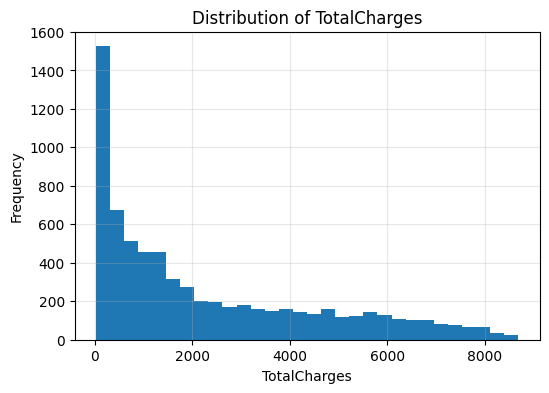

In [ ]:
for col in numerical_cols:
  plt.figure(figsize=(6, 4))
  plt.hist(df[col], bins=30)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.grid(True, alpha=0.3)
  plt.show()

## Distribution Insights

- 'tenure' shows concentrations at both low and high values;
- 'MonthlyCharges' appears multimodal;
- 'TotalCharges' is strongly right-skewed;
- no obvious anomalies are visible in the numerical distributions.

## Churn by Numerical Features

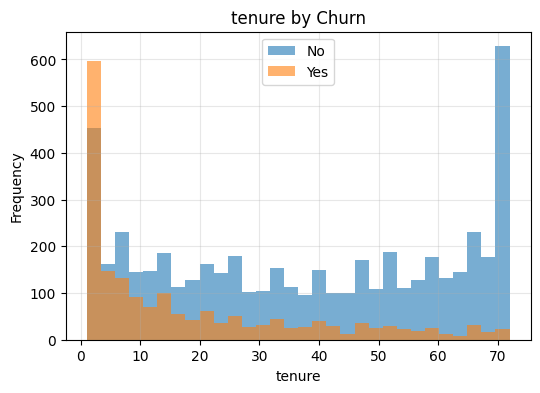

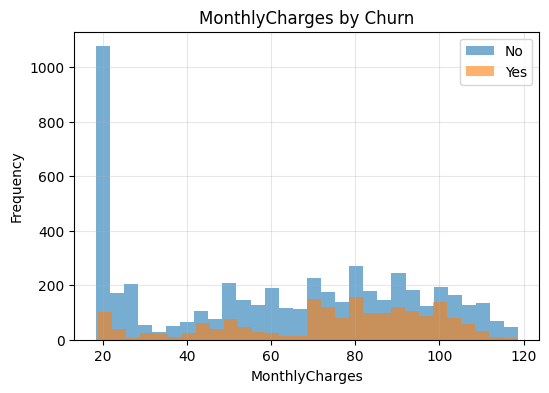

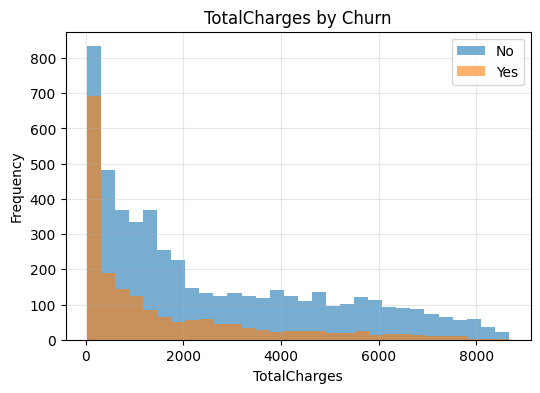

In [ ]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
  plt.figure(figsize=(6, 4))
  plt.hist(df[df["Churn"] == "No"][col], bins=30, alpha=0.6, label="No")
  plt.hist(df[df["Churn"] == "Yes"][col], bins=30, alpha=0.6, label="Yes")
  plt.title(f"{col} by Churn")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

## Churn Patterns in Numerical Features

- customers who churn tend to have lower 'tenure', indicating that newer customers are more likely to leave;
- churned customers are more concentrated at higher 'MonthlyCharges';
- 'TotalCharges' for churned customers is generally lower, which is consistent with shorter customer lifetime.

## Categorical Features

We analyze categorical variables to understand customer segments and identify factors associated with churn.

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("Churn")
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

## Churn Rate by Categorical Feature

In [ ]:
selected_cat_cols = ["gender", "Partner", "Dependents", "InternetService", "Contract", "PaymentMethod"]

for col in selected_cat_cols:
  churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index")
  print(f"\nChurn rate by {col}")
  print(churn_rate)


Churn rate by gender
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046

Churn rate by Partner
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171

Churn rate by Dependents
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312

Churn rate by InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342

Churn rate by Contract
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487

Churn rate by PaymentMethod
Churn                            No       Yes
PaymentMethod                                
Bank transfer (automatic)  0.832685  0.167315
Credit c

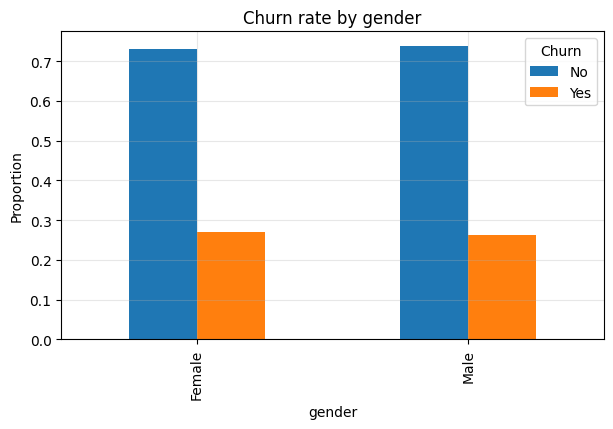

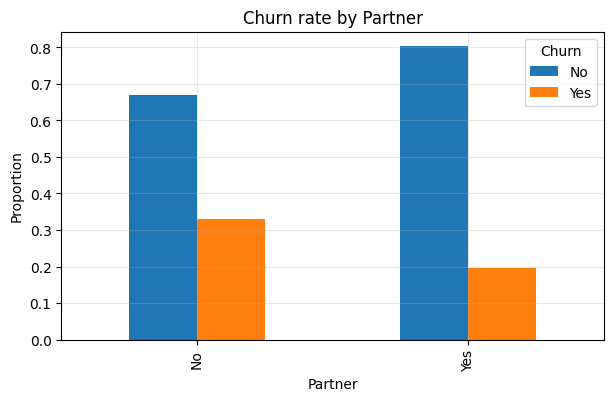

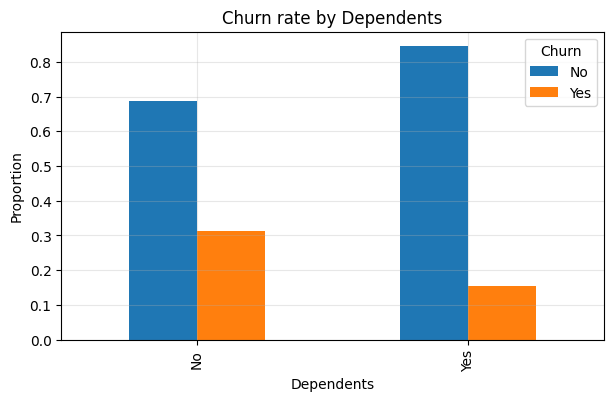

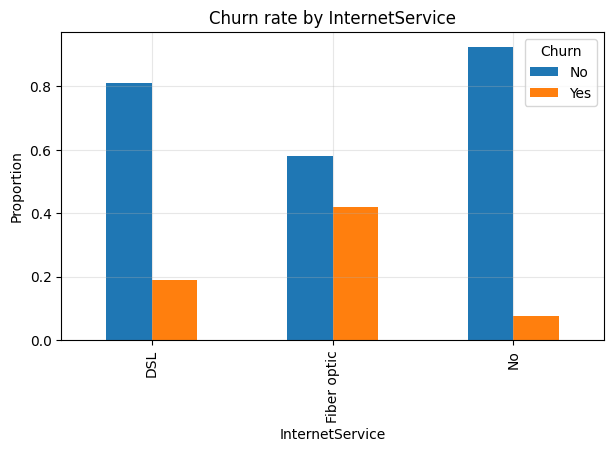

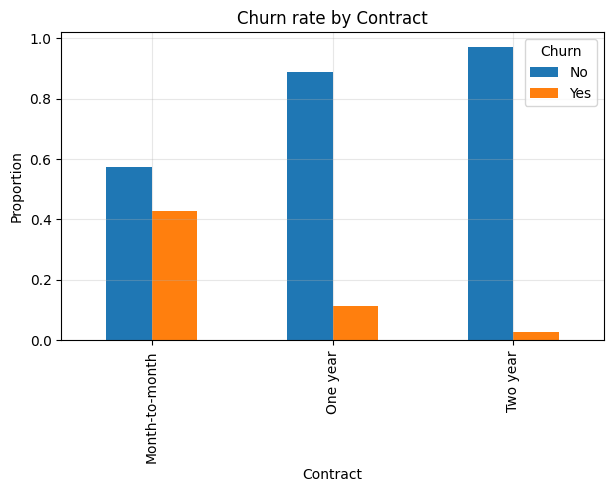

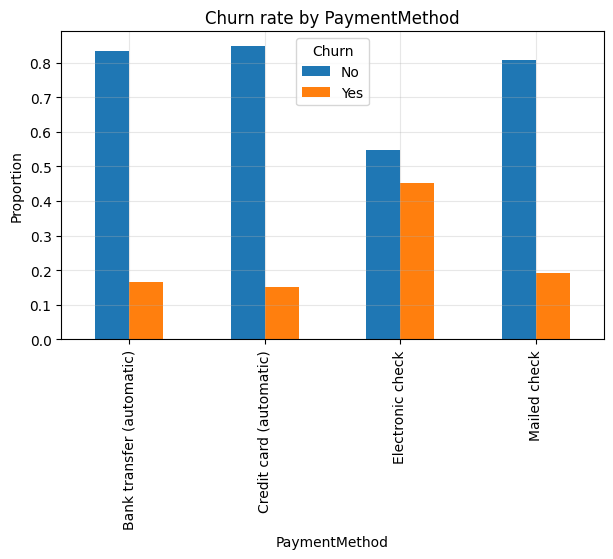

In [ ]:
for col in selected_cat_cols:
  churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index")
  churn_rate.plot(kind="bar", figsize=(7, 4))
  plt.title(f"Churn rate by {col}")
  plt.ylabel("Proportion")
  plt.grid(True, alpha=0.3)
  plt.show()

## Categorical Feature Insights

The categorical analysis reveals several strong relationships with churn:

- 'gender' shows almost no difference in churn rates;
- customers without a 'Partner' or 'Dependents' churn more often;
- 'Fiber optic' customers have the highest churn among internet service types;
- 'Month-to-month' contracts are strongly associated with churn;
- customers using 'Electronic check' have the highest churn rate.

These variables are likely to be important predictors for the classification model.

## Final EDA Conclusion

The exploratory data analysis revealed several important patterns in the dataset.

The target variable is moderately imbalanced, with approximately 26.6% of customers churning.

Among numerical features, `tenure`, `MonthlyCharges`, and `TotalCharges` show noticeable differences between churn groups.

Among categorical variables, the strongest relationships with churn were observed for `Contract`, `InternetService`, `PaymentMethod`, `Partner`, and `Dependents`.

In particular, customers with month-to-month contracts, fiber optic internet service, and electronic check payment method demonstrate significantly higher churn rates.

These findings suggest that both numerical and categorical variables contain strong predictive information and are likely to contribute substantially to the classification model.

In [ ]:
df.to_csv("telco_churn_cleaned.csv", index=False)